# Analyse der Quellenkonsistenz bei identischen LLM-Anfragen

Dieses Notebook wertet die Datei `sources_no_grounding_temp1.csv.txt` aus. Ziel ist es, die Stabilität der genannten Quellen über wiederholte identische Prompts hinweg zu messen.

Untersucht werden zwei Ebenen:

- **URL-Ebene:** Werden exakt dieselben URLs erneut genannt?
- **Domain-Ebene:** Werden zumindest dieselben Anbieter / Institutionen erneut genannt?

Wichtig für das Paper: Konsistenz bedeutet hier **nicht**, dass eine Quelle inhaltlich korrekt oder passend ist. Die Analyse misst nur Wiederholbarkeit der Quellenangaben.

## 1. Setup

Passe bei Bedarf nur `SOURCE_FILE` an. Die Datei kann `.csv` oder `.csv.txt` heißen, solange sie CSV-Struktur hat.

In [ ]:
from pathlib import Path
from itertools import combinations
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

SOURCE_FILE = Path("../data/processed/sources_no_grounding_temp1.csv")

Verwendete Datei: ..\data\processed\sources_no_grounding_temp1.csv


## 2. Daten laden und prüfen

Die Datei enthält pro Zeile eine extrahierte Quelle. Ein Run mit drei Quellen kommt also dreimal vor.

In [8]:
df = pd.read_csv(SOURCE_FILE)

# Kleine Bereinigung für robuste Auswertung
for col in ["prompt_id", "category", "run_id", "model", "url", "domain", "title", "source_extraction_method"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Domains notfalls aus URLs ableiten
if "domain" not in df.columns or df["domain"].isna().all():
    df["domain"] = df["url"].apply(lambda u: urlparse(str(u)).netloc.lower().removeprefix("www."))
else:
    missing_domain = df["domain"].isna() | (df["domain"] == "")
    df.loc[missing_domain, "domain"] = df.loc[missing_domain, "url"].apply(
        lambda u: urlparse(str(u)).netloc.lower().removeprefix("www.")
    )

# URL-Normalisierung: sehr vorsichtig, damit echte Unterschiede nicht weggebügelt werden.
df["url_norm"] = (
    df["url"]
    .astype("string")
    .str.strip()
    .str.replace(r"#.*$", "", regex=True)
    .str.rstrip("/")
)

df["domain_norm"] = (
    df["domain"]
    .astype("string")
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
    .str.strip()
)

print("Zeilen / Quellen:", len(df))
print("Spalten:", list(df.columns))
display(df.head())

Zeilen / Quellen: 726
Spalten: ['prompt_id', 'category', 'run_id', 'timestamp', 'model', 'source_index', 'url', 'domain', 'title', 'source_extraction_method', 'url_norm', 'domain_norm']


,prompt_id,category,run_id,timestamp,model,source_index,url,domain,title,source_extraction_method,url_norm,domain_norm
0,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,0,https://www.ipcc.ch/report/ar6/syr/,ipcc.ch,<NA>,text_regex,https://www.ipcc.ch/report/ar6/syr,ipcc.ch
1,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,1,https://www.deutsches-klima-konsortium.de/de/k...,deutsches-klima-konsortium.de,<NA>,text_regex,https://www.deutsches-klima-konsortium.de/de/k...,deutsches-klima-konsortium.de
2,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,2,https://climate.nasa.gov/,climate.nasa.gov,<NA>,text_regex,https://climate.nasa.gov,climate.nasa.gov
3,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,3,https://public.wmo.int/en/our-mandate/climate/...,public.wmo.int,<NA>,text_regex,https://public.wmo.int/en/our-mandate/climate/...,public.wmo.int
4,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,4,https://www.klimafakten.de/,klimafakten.de,<NA>,text_regex,https://www.klimafakten.de,klimafakten.de


### Methodischer Hinweis zur Quellenextraktion

Falls `source_extraction_method` den Wert `text_regex` enthält, stammen die Quellen aus im Antworttext erkannten URLs. Dann misst die Analyse die Stabilität der **explizit ausgegebenen URLs**, nicht die Stabilität interner Grounding-Metadaten.

Das ist nicht falsch, muss aber im Methodikteil sauber benannt werden.

In [9]:
if "source_extraction_method" in df.columns:
    display(df["source_extraction_method"].value_counts(dropna=False).rename("Anzahl"))

if "model" in df.columns:
    display(df["model"].value_counts(dropna=False).rename("Anzahl"))

source_extraction_method
text_regex    726
Name: Anzahl, dtype: Int64

model
gemini-3.1-flash-lite    726
Name: Anzahl, dtype: Int64

## 3. Datenqualität und Umfang

Diese Tabellen gehören fast direkt in den Ergebnisteil oder die Methodik.

In [10]:
# Anzahl Quellen je Run
sources_per_run = (
    df.groupby(["prompt_id", "category", "run_id"], as_index=False)
      .agg(
          n_sources=("url_norm", "nunique"),
          n_domains=("domain_norm", "nunique"),
          first_timestamp=("timestamp", "min") if "timestamp" in df.columns else ("url_norm", "size")
      )
)

run_overview = (
    sources_per_run.groupby(["category", "prompt_id"], as_index=False)
    .agg(
        runs=("run_id", "nunique"),
        mean_sources_per_run=("n_sources", "mean"),
        min_sources_per_run=("n_sources", "min"),
        max_sources_per_run=("n_sources", "max"),
        mean_domains_per_run=("n_domains", "mean"),
    )
)

category_overview = (
    run_overview.groupby("category", as_index=False)
    .agg(
        prompts=("prompt_id", "nunique"),
        runs=("runs", "sum"),
        mean_sources_per_run=("mean_sources_per_run", "mean"),
        mean_domains_per_run=("mean_domains_per_run", "mean"),
    )
)

print("Überblick nach Kategorie")
display(category_overview)

print("Überblick nach Prompt")
display(run_overview)

Überblick nach Kategorie


,category,prompts,runs,mean_sources_per_run,mean_domains_per_run
0,Aktuelles Thema,3,60,4.466667,4.100000
1,Faktische Frage,4,80,3.337500,2.925000
2,Prozedurale Frage,3,60,3.166667,1.833333


Überblick nach Prompt


,category,prompt_id,runs,mean_sources_per_run,min_sources_per_run,max_sources_per_run,mean_domains_per_run
0,Aktuelles Thema,P08,20,3.50,3,4,3.50
1,Aktuelles Thema,P09,20,4.45,3,6,4.45
2,Aktuelles Thema,P10,20,5.45,4,8,4.35
3,Faktische Frage,P01,20,7.05,5,10,6.05
4,Faktische Frage,P02,20,2.25,2,3,2.25
5,Faktische Frage,P03,20,1.65,1,3,1.10
6,Faktische Frage,P04,20,2.40,2,3,2.30
7,Prozedurale Frage,P05,20,3.80,2,5,1.60
8,Prozedurale Frage,P06,20,3.15,2,5,2.85
9,Prozedurale Frage,P07,20,2.55,1,5,1.05


## 4. Pairwise Jaccard Similarity berechnen

Für jeden Prompt werden alle Run-Paare verglichen. Bei 20 Runs entstehen pro Prompt 190 Paarvergleiche.

Formel:

\[
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
\]

- `1.0` bedeutet: identische Quellenmenge
- `0.0` bedeutet: keine Überschneidung

In [11]:
def jaccard(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

# Sets pro Prompt und Run bilden
run_sets = (
    df.groupby(["prompt_id", "category", "run_id"])
      .agg(
          urls=("url_norm", lambda x: set(x.dropna())),
          domains=("domain_norm", lambda x: set(x.dropna())),
          n_sources=("url_norm", "nunique"),
          n_domains=("domain_norm", "nunique"),
      )
      .reset_index()
)

pairwise_rows = []
for (prompt_id, category), group in run_sets.groupby(["prompt_id", "category"]):
    records = group.to_dict("records")
    for a, b in combinations(records, 2):
        url_j = jaccard(a["urls"], b["urls"])
        domain_j = jaccard(a["domains"], b["domains"])
        pairwise_rows.append({
            "prompt_id": prompt_id,
            "category": category,
            "run_a": a["run_id"],
            "run_b": b["run_id"],
            "url_jaccard": url_j,
            "domain_jaccard": domain_j,
            "url_overlap": int(url_j > 0) if not pd.isna(url_j) else np.nan,
            "domain_overlap": int(domain_j > 0) if not pd.isna(domain_j) else np.nan,
        })

pairwise = pd.DataFrame(pairwise_rows)

print("Paarvergleiche:", len(pairwise))
display(pairwise.head())

Paarvergleiche: 1900


,prompt_id,category,run_a,run_b,url_jaccard,domain_jaccard,url_overlap,domain_overlap
0,P01,Faktische Frage,P01_R01,P01_R02,0.166667,0.333333,1,1
1,P01,Faktische Frage,P01_R01,P01_R03,0.250000,0.250000,1,1
2,P01,Faktische Frage,P01_R01,P01_R04,0.428571,0.666667,1,1
3,P01,Faktische Frage,P01_R01,P01_R05,0.111111,0.250000,1,1
4,P01,Faktische Frage,P01_R01,P01_R06,0.181818,0.222222,1,1


## 5. Wichtigste Ergebnistabelle: Konsistenz pro Prompt

Diese Tabelle ist der Kern der Analyse. Sie beantwortet, welche Prompts stabile oder instabile Quellenangaben erzeugen.

In [12]:
unique_counts = (
    df.groupby(["prompt_id", "category"])
      .agg(
          unique_urls=("url_norm", "nunique"),
          unique_domains=("domain_norm", "nunique"),
          total_source_mentions=("url_norm", "count"),
      )
      .reset_index()
)

run_counts = (
    run_sets.groupby(["prompt_id", "category"])
      .agg(
          runs=("run_id", "nunique"),
          mean_sources_per_run=("n_sources", "mean"),
          mean_domains_per_run=("n_domains", "mean"),
      )
      .reset_index()
)

jaccard_summary = (
    pairwise.groupby(["prompt_id", "category"])
      .agg(
          mean_url_jaccard=("url_jaccard", "mean"),
          median_url_jaccard=("url_jaccard", "median"),
          mean_domain_jaccard=("domain_jaccard", "mean"),
          median_domain_jaccard=("domain_jaccard", "median"),
          url_pair_overlap_rate=("url_overlap", "mean"),
          domain_pair_overlap_rate=("domain_overlap", "mean"),
          pairwise_comparisons=("url_jaccard", "count"),
      )
      .reset_index()
)

prompt_summary = (
    run_counts.merge(unique_counts, on=["prompt_id", "category"], how="left")
              .merge(jaccard_summary, on=["prompt_id", "category"], how="left")
              .sort_values("prompt_id")
)

# Lesbarer runden
prompt_summary_rounded = prompt_summary.copy()
for col in prompt_summary_rounded.select_dtypes(include="number").columns:
    if "runs" not in col and "unique" not in col and "total" not in col and "comparisons" not in col:
        prompt_summary_rounded[col] = prompt_summary_rounded[col].round(3)

prompt_summary_rounded

,prompt_id,category,runs,mean_sources_per_run,mean_domains_per_run,unique_urls,unique_domains,total_source_mentions,mean_url_jaccard,median_url_jaccard,mean_domain_jaccard,median_domain_jaccard,url_pair_overlap_rate,domain_pair_overlap_rate,pairwise_comparisons
0,P01,Faktische Frage,20,7.05,6.05,49,21,142,0.198,0.182,0.358,0.333,0.963,1.000,190
1,P02,Faktische Frage,20,2.25,2.25,23,7,45,0.301,0.333,0.442,0.333,1.000,1.000,190
2,P03,Faktische Frage,20,1.65,1.10,28,3,33,0.011,0.000,0.902,1.000,0.032,1.000,190
3,P04,Faktische Frage,20,2.40,2.30,30,7,48,0.097,0.000,0.582,0.667,0.305,0.968,190
4,P05,Prozedurale Frage,20,3.80,1.60,41,8,76,0.057,0.000,0.572,0.500,0.342,1.000,190
5,P06,Prozedurale Frage,20,3.15,2.85,37,4,63,0.125,0.143,0.811,0.750,0.532,1.000,190
6,P07,Prozedurale Frage,20,2.55,1.05,10,2,51,0.433,0.333,0.950,1.000,1.000,1.000,190
7,P08,Aktuelles Thema,20,3.50,3.50,23,13,70,0.261,0.200,0.559,0.500,0.721,1.000,190
8,P09,Aktuelles Thema,20,4.45,4.45,30,14,89,0.196,0.143,0.509,0.500,0.926,1.000,190
9,P10,Aktuelles Thema,20,5.45,4.35,92,11,109,0.013,0.000,0.571,0.600,0.095,1.000,190


## 6. Kategorievergleich

Diese Tabelle ist hilfreich, um zu prüfen, ob z. B. aktuelle Themen weniger stabil sind als faktische oder prozedurale Fragen.

In [13]:
category_summary = (
    prompt_summary.groupby("category")
    .agg(
        prompts=("prompt_id", "nunique"),
        mean_url_jaccard=("mean_url_jaccard", "mean"),
        mean_domain_jaccard=("mean_domain_jaccard", "mean"),
        mean_unique_urls=("unique_urls", "mean"),
        mean_unique_domains=("unique_domains", "mean"),
        mean_sources_per_run=("mean_sources_per_run", "mean"),
        mean_domains_per_run=("mean_domains_per_run", "mean"),
    )
    .reset_index()
)

category_summary_rounded = category_summary.copy()
for col in category_summary_rounded.select_dtypes(include="number").columns:
    if col != "prompts":
        category_summary_rounded[col] = category_summary_rounded[col].round(3)

category_summary_rounded

,category,prompts,mean_url_jaccard,mean_domain_jaccard,mean_unique_urls,mean_unique_domains,mean_sources_per_run,mean_domains_per_run
0,Aktuelles Thema,3,0.156,0.546,48.333,12.667,4.467,4.100
1,Faktische Frage,4,0.152,0.571,32.500,9.500,3.338,2.925
2,Prozedurale Frage,3,0.205,0.778,29.333,4.667,3.167,1.833


## 7. Grafik: URL- und Domain-Jaccard pro Prompt

Diese Grafik zeigt meistens den wichtigsten Unterschied: Auf Domain-Ebene sind Systeme oft stabiler als auf URL-Ebene.

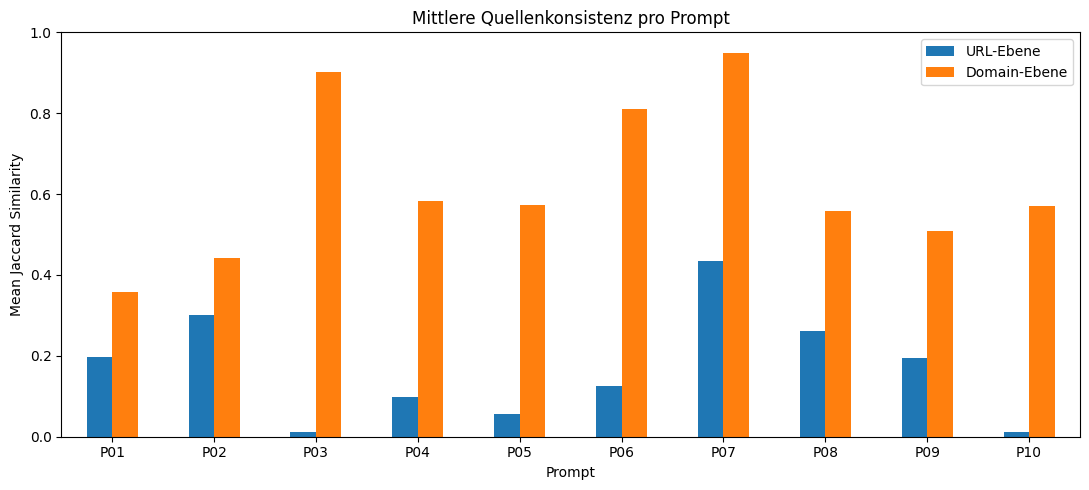

In [14]:
plot_df = prompt_summary.set_index("prompt_id")[["mean_url_jaccard", "mean_domain_jaccard"]]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Mittlere Quellenkonsistenz pro Prompt")
ax.set_xlabel("Prompt")
ax.set_ylabel("Mean Jaccard Similarity")
ax.set_ylim(0, 1)
ax.legend(["URL-Ebene", "Domain-Ebene"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Grafik: Verteilung der Jaccard-Werte nach Kategorie

Die Boxplots zeigen die Streuung aller Run-Paarvergleiche innerhalb der Kategorien.

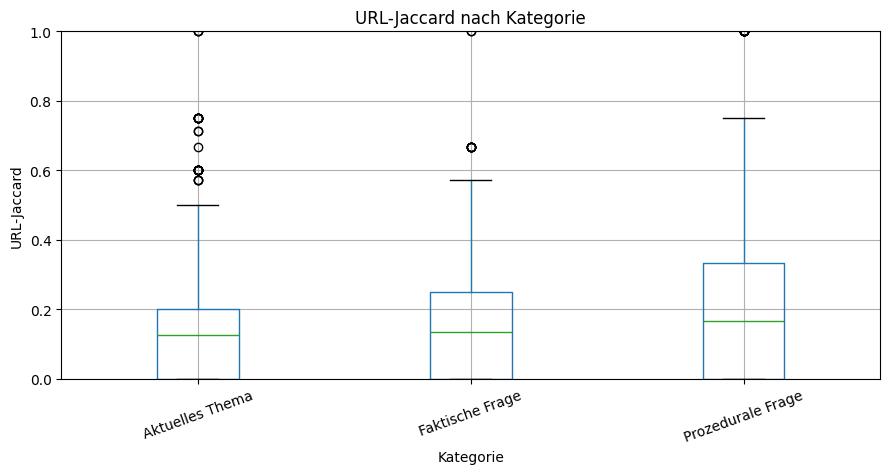

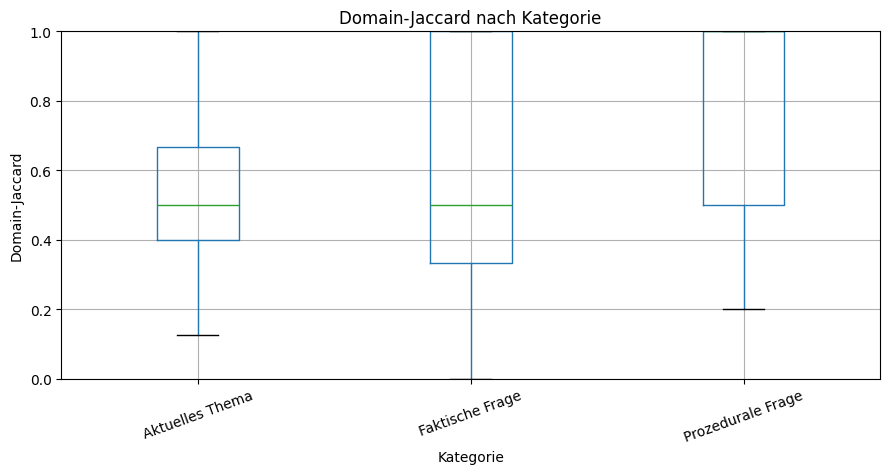

In [15]:
# URL-Jaccard nach Kategorie
fig, ax = plt.subplots(figsize=(9, 5))
pairwise.boxplot(column="url_jaccard", by="category", ax=ax)
ax.set_title("URL-Jaccard nach Kategorie")
ax.set_xlabel("Kategorie")
ax.set_ylabel("URL-Jaccard")
ax.set_ylim(0, 1)
plt.suptitle("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Domain-Jaccard nach Kategorie
fig, ax = plt.subplots(figsize=(9, 5))
pairwise.boxplot(column="domain_jaccard", by="category", ax=ax)
ax.set_title("Domain-Jaccard nach Kategorie")
ax.set_xlabel("Kategorie")
ax.set_ylabel("Domain-Jaccard")
ax.set_ylim(0, 1)
plt.suptitle("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 9. Stabilste und instabilste Prompts

Diese Tabelle eignet sich gut für einen kurzen Fallvergleich im Paper.

In [16]:
stability_ranking = prompt_summary_rounded[[
    "prompt_id", "category", "runs", "mean_url_jaccard", "mean_domain_jaccard",
    "unique_urls", "unique_domains", "mean_sources_per_run"
]].sort_values(["mean_domain_jaccard", "mean_url_jaccard"], ascending=False)

print("Stabilste Prompts")
display(stability_ranking.head(5))

print("Instabilste Prompts")
display(stability_ranking.tail(5).sort_values(["mean_domain_jaccard", "mean_url_jaccard"]))

Stabilste Prompts


,prompt_id,category,runs,mean_url_jaccard,mean_domain_jaccard,unique_urls,unique_domains,mean_sources_per_run
6,P07,Prozedurale Frage,20,0.433,0.950,10,2,2.55
2,P03,Faktische Frage,20,0.011,0.902,28,3,1.65
5,P06,Prozedurale Frage,20,0.125,0.811,37,4,3.15
3,P04,Faktische Frage,20,0.097,0.582,30,7,2.40
4,P05,Prozedurale Frage,20,0.057,0.572,41,8,3.80


Instabilste Prompts


,prompt_id,category,runs,mean_url_jaccard,mean_domain_jaccard,unique_urls,unique_domains,mean_sources_per_run
0,P01,Faktische Frage,20,0.198,0.358,49,21,7.05
1,P02,Faktische Frage,20,0.301,0.442,23,7,2.25
8,P09,Aktuelles Thema,20,0.196,0.509,30,14,4.45
7,P08,Aktuelles Thema,20,0.261,0.559,23,13,3.50
9,P10,Aktuelles Thema,20,0.013,0.571,92,11,5.45


## 10. Heatmap: Run-vs-Run-Ähnlichkeit

Die Heatmap ist für einzelne Beispiele sehr anschaulich. Für das Paper reichen meist 1–3 Prompts:

- stabilster Prompt
- mittlerer Prompt
- instabilster Prompt

Beispiele: {'stabil': 'P07', 'mittel': 'P10', 'instabil': 'P01'}


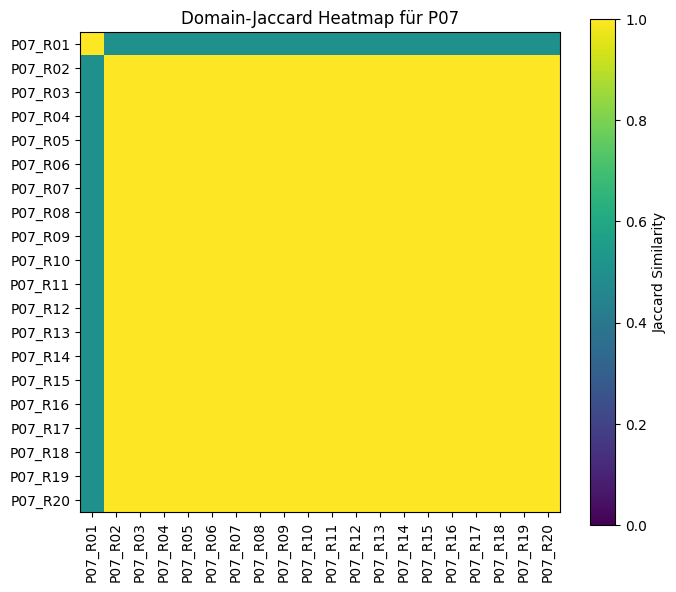

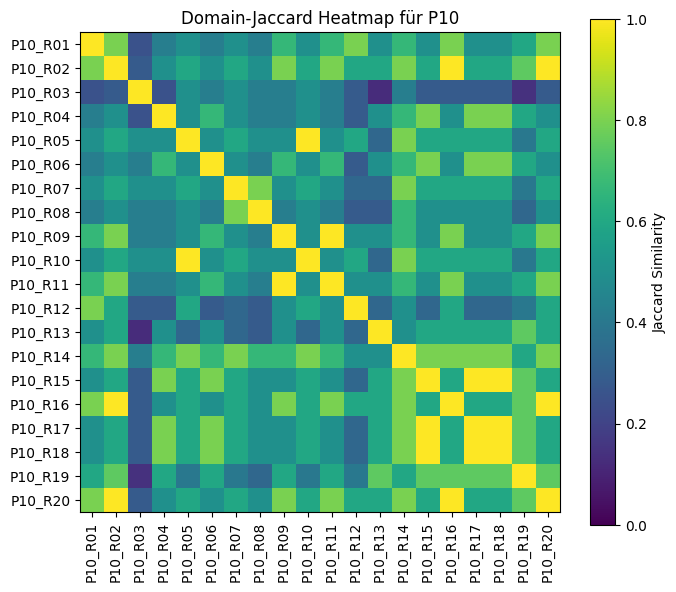

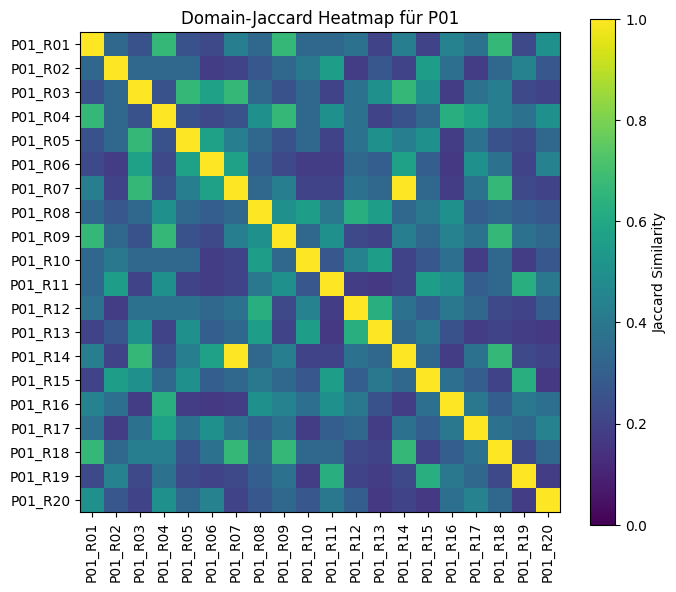

In [17]:
def similarity_matrix(prompt_id, level="domain"):
    value_col = "domain_jaccard" if level == "domain" else "url_jaccard"
    subset = pairwise[pairwise["prompt_id"] == prompt_id]
    runs = sorted(run_sets.loc[run_sets["prompt_id"] == prompt_id, "run_id"].unique())
    mat = pd.DataFrame(np.eye(len(runs)), index=runs, columns=runs)

    for _, row in subset.iterrows():
        mat.loc[row["run_a"], row["run_b"]] = row[value_col]
        mat.loc[row["run_b"], row["run_a"]] = row[value_col]

    return mat


def plot_similarity_heatmap(prompt_id, level="domain"):
    mat = similarity_matrix(prompt_id, level=level)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(mat.values, vmin=0, vmax=1)
    ax.set_title(f"{level.capitalize()}-Jaccard Heatmap für {prompt_id}")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_yticklabels(mat.index)
    fig.colorbar(im, ax=ax, label="Jaccard Similarity")
    plt.tight_layout()
    plt.show()

# Automatisch Beispiele auswählen
stable_prompt = stability_ranking.iloc[0]["prompt_id"]
unstable_prompt = stability_ranking.iloc[-1]["prompt_id"]
middle_prompt = stability_ranking.iloc[len(stability_ranking) // 2]["prompt_id"]

print("Beispiele:", {"stabil": stable_prompt, "mittel": middle_prompt, "instabil": unstable_prompt})

for pid in [stable_prompt, middle_prompt, unstable_prompt]:
    plot_similarity_heatmap(pid, level="domain")

## 11. Häufigste Domains insgesamt

Diese Tabelle zeigt, welche Domains die Quellenauswahl dominieren. Das ist besonders für die Diskussion relevant, weil stabile Domains nicht automatisch korrekte oder passende Quellen bedeuten.

In [18]:
domain_frequency = (
    df.groupby("domain_norm")
    .agg(
        mentions=("domain_norm", "count"),
        prompts=("prompt_id", "nunique"),
        runs=("run_id", "nunique"),
        categories=("category", lambda x: ", ".join(sorted(set(x.dropna())))),
    )
    .reset_index()
    .sort_values(["mentions", "prompts", "runs"], ascending=False)
)

domain_frequency.head(25)

,domain_norm,mentions,prompts,runs,categories
2,arbeitsagentur.de,64,1,20,Prozedurale Frage
60,service.berlin.de,50,1,20,Prozedurale Frage
42,ipcc.ch,37,1,20,Faktische Frage
62,statistik-berlin-brandenburg.de,31,1,20,Faktische Frage
66,tagesschau.de,29,1,20,Aktuelles Thema
11,bundesnetzagentur.de,24,2,24,"Aktuelles Thema, Prozedurale Frage"
77,verbraucherzentrale.de,24,1,20,Prozedurale Frage
23,climate.nasa.gov,23,1,20,Faktische Frage
34,gesetze-im-internet.de,21,2,19,"Faktische Frage, Prozedurale Frage"
13,bundesregierung.de,21,2,14,"Aktuelles Thema, Faktische Frage"


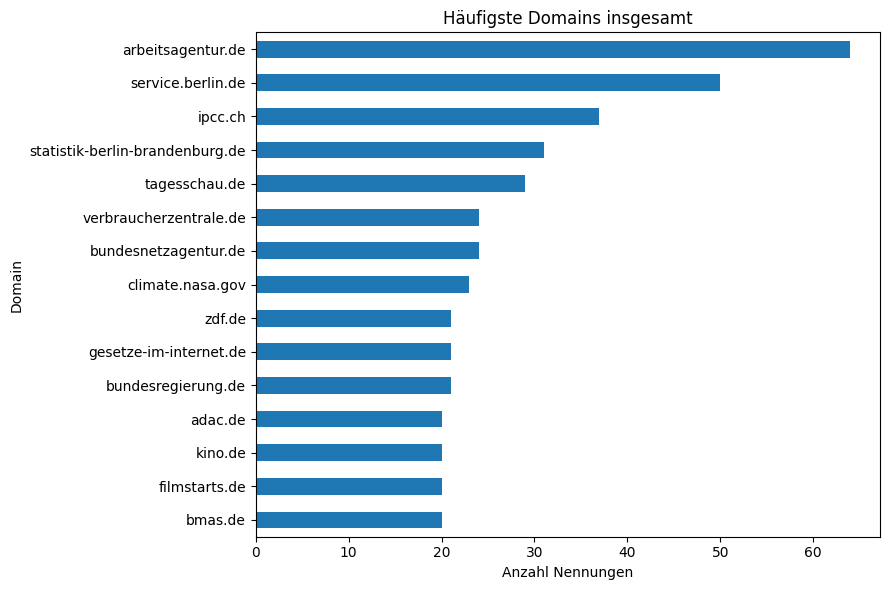

In [19]:
top_domains = domain_frequency.head(15).set_index("domain_norm")["mentions"].sort_values()

ax = top_domains.plot(kind="barh", figsize=(9, 6))
ax.set_title("Häufigste Domains insgesamt")
ax.set_xlabel("Anzahl Nennungen")
ax.set_ylabel("Domain")
plt.tight_layout()
plt.show()

## 12. Domain-Frequenzen pro Prompt

Diese Funktion ist nützlich für Fallanalysen. Sie zeigt, welche Domains bei einem Prompt über die 20 Runs hinweg immer wieder erscheinen.

In [20]:
def domain_frequency_for_prompt(prompt_id, top_n=15):
    subset = df[df["prompt_id"] == prompt_id]
    freq = (
        subset.groupby("domain_norm")
        .agg(
            mentions=("domain_norm", "count"),
            runs=("run_id", "nunique"),
            unique_urls=("url_norm", "nunique"),
        )
        .reset_index()
        .sort_values(["runs", "mentions"], ascending=False)
    )
    return freq.head(top_n)

example_prompt = stable_prompt
print("Beispielprompt:", example_prompt)
display(domain_frequency_for_prompt(example_prompt))

Beispielprompt: P07


,domain_norm,mentions,runs,unique_urls
1,service.berlin.de,50,20,9
0,berlin.de,1,1,1


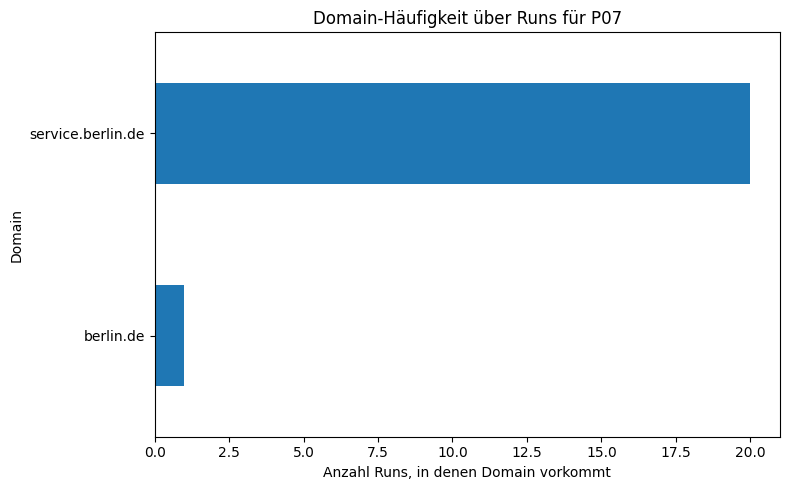

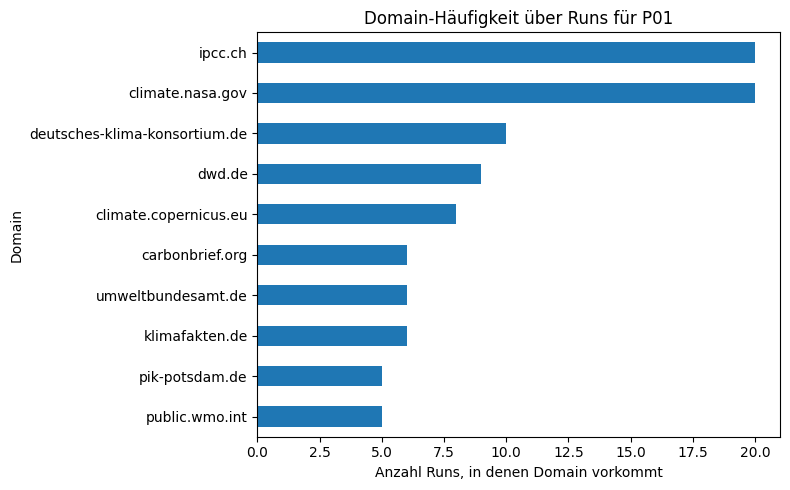

In [21]:
def plot_domain_frequency_for_prompt(prompt_id, top_n=10):
    freq = domain_frequency_for_prompt(prompt_id, top_n=top_n)
    plot_data = freq.set_index("domain_norm")["runs"].sort_values()
    ax = plot_data.plot(kind="barh", figsize=(8, 5))
    ax.set_title(f"Domain-Häufigkeit über Runs für {prompt_id}")
    ax.set_xlabel("Anzahl Runs, in denen Domain vorkommt")
    ax.set_ylabel("Domain")
    plt.tight_layout()
    plt.show()

plot_domain_frequency_for_prompt(stable_prompt)
plot_domain_frequency_for_prompt(unstable_prompt)

## 13. Optional: URL- vs. Domain-Stabilität direkt vergleichen

Diese Tabelle zeigt, wie viel stabiler die Domain-Ebene gegenüber der URL-Ebene ist.

In [22]:
prompt_summary_rounded["domain_minus_url_jaccard"] = (
    prompt_summary_rounded["mean_domain_jaccard"] - prompt_summary_rounded["mean_url_jaccard"]
).round(3)

comparison_table = prompt_summary_rounded[[
    "prompt_id", "category", "mean_url_jaccard", "mean_domain_jaccard", "domain_minus_url_jaccard"
]].sort_values("domain_minus_url_jaccard", ascending=False)

comparison_table

,prompt_id,category,mean_url_jaccard,mean_domain_jaccard,domain_minus_url_jaccard
2,P03,Faktische Frage,0.011,0.902,0.891
5,P06,Prozedurale Frage,0.125,0.811,0.686
9,P10,Aktuelles Thema,0.013,0.571,0.558
6,P07,Prozedurale Frage,0.433,0.950,0.517
4,P05,Prozedurale Frage,0.057,0.572,0.515
3,P04,Faktische Frage,0.097,0.582,0.485
8,P09,Aktuelles Thema,0.196,0.509,0.313
7,P08,Aktuelles Thema,0.261,0.559,0.298
0,P01,Faktische Frage,0.198,0.358,0.160
1,P02,Faktische Frage,0.301,0.442,0.141


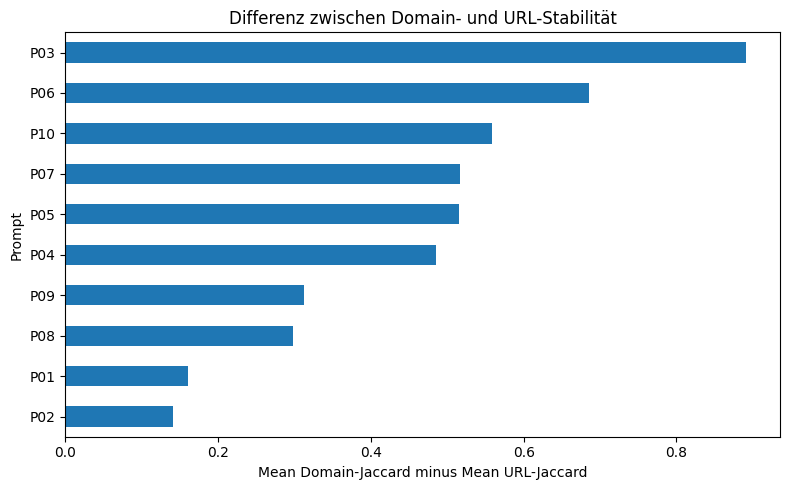

In [23]:
plot_data = comparison_table.set_index("prompt_id")["domain_minus_url_jaccard"].sort_values()
ax = plot_data.plot(kind="barh", figsize=(8, 5))
ax.set_title("Differenz zwischen Domain- und URL-Stabilität")
ax.set_xlabel("Mean Domain-Jaccard minus Mean URL-Jaccard")
ax.set_ylabel("Prompt")
plt.tight_layout()
plt.show()

## 14. Tabellen für Paper exportieren

Die folgenden CSV-Dateien kannst du direkt für dein Paper oder zur weiteren Bearbeitung verwenden.

In [24]:
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

prompt_summary_rounded.to_csv(OUTPUT_DIR / "prompt_summary.csv", index=False)
category_summary_rounded.to_csv(OUTPUT_DIR / "category_summary.csv", index=False)
domain_frequency.to_csv(OUTPUT_DIR / "domain_frequency.csv", index=False)
pairwise.to_csv(OUTPUT_DIR / "pairwise_jaccard.csv", index=False)

print("Exportiert nach:", OUTPUT_DIR.resolve())
print("- prompt_summary.csv")
print("- category_summary.csv")
print("- domain_frequency.csv")
print("- pairwise_jaccard.csv")

Exportiert nach: C:\Users\lenaf\vscProjects\llm-quellenkonsistenz\notebooks\analysis_outputs
- prompt_summary.csv
- category_summary.csv
- domain_frequency.csv
- pairwise_jaccard.csv


## 15. Formulierungshilfe für den Ergebnisteil

Diese Stichpunkte kannst du nach dem Ausführen des Notebooks mit deinen konkreten Zahlen füllen:

- Auf URL-Ebene liegt die mittlere Jaccard Similarity zwischen `...` und `...`.
- Auf Domain-Ebene liegt die mittlere Jaccard Similarity zwischen `...` und `...`.
- Die Domain-Ebene ist damit stabiler / nicht stabiler als die konkrete URL-Ebene.
- Besonders stabil ist Prompt `...`, besonders instabil ist Prompt `...`.
- Die häufigsten Domains sind `...`, `...` und `...`.
- Die Ergebnisse zeigen, dass Quellenangaben bei identischen Prompts nicht nur vom Thema, sondern auch von der Granularität der Betrachtung abhängen: konkrete URLs schwanken stärker als Domains.

Nicht schreiben: „Das Modell ist zuverlässig, weil dieselben Domains erscheinen.“  
Besser schreiben: „Die wiederholte Nennung einzelner Domains zeigt Quellenstabilität auf Anbieter-Ebene, erlaubt aber keine Aussage über die inhaltliche Korrektheit oder Stützung der Antwort.“